# Assignment 5 - Out-Of-Sample Long-Only Mean Reversion


## Research Objective And Frozen Design

The idea notebook selected a volatility-scaled weekly reversal score during the 2010-2019 development period. This notebook evaluates that frozen signal out of sample from January 2020 onward, using long-only implementations that can be traded after the professor tradability filters.

The analysis is organized in three implementation layers:

1. direct EWMA strategies, where the score rule itself defines the holdings and smoothing controls turnover;
2. Black-Litterman signal-tilted portfolios, where the same signal baskets become benchmark-aware views solved through the professor optimizer;
3. turnover-aware tracking-error portfolios, where the optimizer tracks the unsmoothed signal target only when the tracking benefit compensates for trading cost.

The main evaluation remains economic: net performance after turnover, 20 bps variable transaction costs and the 1% annual fee. SPI is used as the passive benchmark throughout.


## Configuration, Data And Frozen Score

The configuration records all frozen research choices used by the out-of-sample test: signal construction, tradability filters, EWMA implementation parameters, transaction costs and reporting assumptions. These parameters should be changed here, not scattered across later cells.


In [127]:
import importlib
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

pd.options.display.float_format = "{:,.4f}".format

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir() or not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir() or not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError("Run this notebook from the repository root or assignments folder.")

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from helper_functions import load_data_spi, load_jkp_factor_series
from backtesting.backtest import Backtest
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest_item_builder.bib_classes import OptimizationItemBuilder, SelectionItemBuilder
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_cap_weights,
    bibfn_return_series,
    bibfn_scores,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_box_constraints,
    bibfn_budget_constraint,
    bibfn_turnover_constraint,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_gaps,
    bibfn_selection_jkp_data_scores,
    bibfn_selection_min_volume,
)
from backtesting.portfolio import Portfolio
from estimation.black_litterman import bl_posterior_mu_sigma
from optimization.optimization import Objective, Optimization
import backtesting.backtest as backtest_module
import backtesting.backtest_service as backtest_service_module
import backtesting.strategy as strategy_module

# Reload local framework modules so an already-open notebook kernel picks up
# the patched professor Strategy.simulate implementation consistently.
strategy_module = importlib.reload(strategy_module)
backtest_module = importlib.reload(backtest_module)
backtest_service_module = importlib.reload(backtest_service_module)
Strategy = strategy_module.Strategy
Backtest = backtest_module.Backtest
BacktestService = backtest_service_module.BacktestService


In [128]:
@dataclass(frozen=True)
class StrategyConfig:
    """Frozen assumptions for the out-of-sample long-only implementation."""

    # 1. Execution switches
    run_ewma_strategies: bool = False
    run_black_litterman_strategies: bool = False
    run_tracking_error_strategies: bool = True

    # 2. Out-of-sample window and weekly signal timing
    start_date: str = "2020-01-01"
    end_date: Optional[str] = None
    weekly_resample_rule: str = "W-FRI"
    weekly_min_days: int = 3
    score_lag_weeks: int = 0

    # 3. Frozen volatility-scaled reversal score
    score_field: str = "vol_scaled_reversal"
    vol_lookback_weeks: int = 104
    min_vol_weeks: int = 26

    # 4. Professor-framework tradability filters
    # Liquidity is daily traded monetary value. These values match the code.
    min_median_daily_traded_value: float = 100_000
    volume_window_days: int = 63
    max_zero_volume_gap_days: int = 10
    lookback_days: int = 365

    # 5. Direct long-only implementation choices
    tail_fraction: float = 0.10
    # EWMA adjustment speeds are frozen from the idea-notebook SR maximization
    # on the tradable-universe long contribution of each strategy.
    continuous_ewma_lambda: float = 0.50
    tail_ewma_lambda: float = 0.30
    long_only_gross_exposure: float = 1.00
    # Drop tiny EWMA residual positions before renormalizing.
    min_active_weight: float = 0.001

    # 6. Implementation-cost assumptions
    transaction_cost_bps: int = 20
    fixed_cost_annual: float = 0.01
    show_backtest_progress: bool = True
    trading_days_per_year: int = 252
    rebalances_per_year: int = 52

    # 7. Factor-model benchmark
    factor_names: tuple[str, ...] = ("size", "value", "momentum")
    factor_hac_lags: int = 5

    # 8. Black-Litterman signal-tilted implementation
    # View returns and variances are weekly values frozen from the 2010-2019 idea notebook.
    # Turnover penalty is a tunable one-way cost rate; 0.002 corresponds to 20 bps.
    bl_turnover_penalty: float = 0.002
    # The hard turnover cap is an optional safety constraint, disabled by default.
    bl_use_hard_turnover_cap: bool = False
    bl_turnover_limit: float = 0.30
    bl_stock_upper_bound: float = 0.10
    bl_tau: float = 0.05
    bl_risk_aversion: float = 2.50
    bl_continuous_view_return: float = 0.0023
    bl_continuous_view_variance: float = 0.0008
    bl_tail_view_return: float = 0.0048
    bl_tail_view_variance: float = 0.0020

    # 9. Turnover-aware tracking-error implementation
    tracking_turnover_penalty: float = 0.002
    tracking_turnover_limit: float = 0.50
    tracking_stock_upper_bound: float = 0.05

    # 10. Data locations
    data_dir: Path = DATA_DIR
    results_dir: Path = RESULTS_DIR
    score_path: Path = RESULTS_DIR / "mean_reversion_vol_scaled_scores_oos.parquet"


CONFIG = StrategyConfig()
TC_RATE = CONFIG.transaction_cost_bps / 10_000
CONFIG


StrategyConfig(run_ewma_strategies=False, run_black_litterman_strategies=False, run_tracking_error_strategies=True, start_date='2020-01-01', end_date=None, weekly_resample_rule='W-FRI', weekly_min_days=3, score_lag_weeks=0, score_field='vol_scaled_reversal', vol_lookback_weeks=104, min_vol_weeks=26, min_median_daily_traded_value=100000, volume_window_days=63, max_zero_volume_gap_days=10, lookback_days=365, tail_fraction=0.1, continuous_ewma_lambda=0.5, tail_ewma_lambda=0.3, long_only_gross_exposure=1.0, min_active_weight=0.001, transaction_cost_bps=20, fixed_cost_annual=0.01, show_backtest_progress=True, trading_days_per_year=252, rebalances_per_year=52, factor_names=('size', 'value', 'momentum'), factor_hac_lags=5, bl_turnover_penalty=0.002, bl_use_hard_turnover_cap=False, bl_turnover_limit=0.3, bl_stock_upper_bound=0.1, bl_tau=0.05, bl_risk_aversion=2.5, bl_continuous_view_return=0.0023, bl_continuous_view_variance=0.0008, bl_tail_view_return=0.0048, bl_tail_view_variance=0.002, trac


## Strategy Class Design

The notebook separates portfolio construction into two types of classes, following the economic nature of each implementation rather than forcing every strategy into the same interface.

- The EWMA strategies are **deterministic trading rules**. Once the eligible score vector is known, the target weights are fully specified by ranking, tail selection, smoothing, clipping and renormalization. They therefore inherit from the professor `Strategy` class and directly store a sequence of dated `Portfolio` objects.
- The Black-Litterman implementation is an **expected-return optimization layer**. The signal basket defines a view, but the final portfolio is chosen subject to benchmark information, covariance estimates, long-only bounds, concentration limits and turnover costs.
- The tracking-error implementation is a **target-implementation optimization layer**. The score defines an unsmoothed target portfolio, and the optimizer decides how to move toward that target after pricing turnover while remaining fully invested.
- Performance evaluation is kept consistent once a sequence of portfolios exists. All implemented strategies use professor `Strategy.simulate()` and `Strategy.turnover()` directly, so the return and transaction-cost treatment remains aligned with the framework.

This split keeps the code close to the research logic: direct rules generate holdings directly, while allocation and target-implementation problems are passed to optimizer classes.


## EWMA Strategy Classes

The two direct strategies are deterministic translations of the frozen reversal score into long-only portfolios. They inherit from the professor `Strategy` class because no objective function is being optimized: the signal rule itself defines the raw target weights.

The architecture is:

- build a point-in-time raw target portfolio from the eligible score vector;
- apply EWMA smoothing to reduce turnover;
- remove stocks that are no longer eligible at the current rebalance;
- clip residual EWMA weights below `CONFIG.min_active_weight`;
- renormalize the remaining weights to the configured long-only gross exposure;
- convert each dated weight vector into a professor `Portfolio` object.

The common smoothing rule is:

$$
w^{\mathrm{EWMA}}_t
=
\lambda w^{\mathrm{target}}_t
+
(1-\lambda)w^{\mathrm{EWMA}}_{t-1}.
$$

For the continuous rank-weighted strategy, the raw target weights are based on the positive part of the centered cross-sectional rank:

$$
z_{i,t}
=
2\frac{Rank_t(s_{i,t})-1}{N_t-1}-1,
\qquad
w^{target}_{i,t}
=
\frac{\max(z_{i,t},0)}{\sum_j \max(z_{j,t},0)}.
$$

For the top-tail strategy, the raw target portfolio is an equal-weighted basket of the highest-score stocks:

$$
w^{target}_{i,t}
=
\frac{1}{N^{tail}_t}\mathbf{1}\{i\in Top_q(s_t)\}.
$$

Both classes finally delegate performance evaluation to professor `Strategy.simulate()` and `Strategy.turnover()`.


In [129]:
class ContinuousRankEWMAStrategy(Strategy):
    """Direct Strategy implementation of the score-scaled long-only rule.

    The class does not optimize. It maps each eligible score vector into a raw
    target portfolio, applies EWMA smoothing, and passes the resulting dated
    portfolios to the professor Strategy base class for simulation and turnover.
    """

    def __init__(
        self,
        eligible_scores: dict[pd.Timestamp, pd.Series],
        lambda_value: float,
        gross_exposure: float = 1.0,
        min_active_weight: float = 0.001,
    ):
        self.eligible_scores = {
            pd.Timestamp(date): scores.dropna().sort_index()
            for date, scores in eligible_scores.items()
        }
        self.lambda_value = lambda_value
        self.gross_exposure = gross_exposure
        self.min_active_weight = min_active_weight

        # Step 1: deterministic raw holdings from the signal at each date.
        self.target_weights = self._build_target_weights()
        # Step 2: turnover-aware holdings using w_t = lambda target_t + (1-lambda) w_{t-1}.
        self.weights = self._smooth_target_weights()
        # Step 3: convert the final matrix into professor Portfolio objects.
        super().__init__(self._to_portfolios(self.weights))

    def _build_target_weights(self) -> pd.DataFrame:
        rows = {}
        for date, scores in self.eligible_scores.items():
            if len(scores) < 2 or scores.nunique() < 2:
                continue

            # Centered rank lies in [-1, 1]. The long-only rule keeps only stocks
            # above the cross-sectional median and scales by rank strength.
            ranks = scores.rank(method="average")
            centered_rank = 2 * (ranks - 1) / (len(scores) - 1) - 1
            positive_signal = centered_rank.clip(lower=0.0)

            if positive_signal.sum() > 0:
                rows[date] = self.gross_exposure * positive_signal / positive_signal.sum()
        return pd.DataFrame(rows).T.sort_index().fillna(0.0)

    def _smooth_target_weights(self) -> pd.DataFrame:
        state = pd.Series(0.0, index=self.target_weights.columns)
        rows = {}
        for date, target in self.target_weights.iterrows():
            # EWMA smoothing reduces trading by partially moving toward the new target.
            eligible = pd.Index(self.eligible_scores[date].index)
            state = (1 - self.lambda_value) * state + self.lambda_value * target

            # The strategy cannot keep positions in names that fail today's filters.
            state.loc[~state.index.isin(eligible)] = 0.0
            # EWMA can leave tiny residual positions; remove them to avoid dust trades.
            state.loc[state < self.min_active_weight] = 0.0

            # Renormalize after eligibility and dust-position cuts so the portfolio remains fully invested.
            if state.sum() > 0:
                state = self.gross_exposure * state / state.sum()
                rows[date] = state.copy()
        return pd.DataFrame(rows).T.sort_index().fillna(0.0)

    @staticmethod
    def _to_portfolios(weights: pd.DataFrame) -> list[Portfolio]:
        portfolios = []
        for date, row in weights.iterrows():
            active = row[row.abs() > 0]
            portfolios.append(Portfolio(rebalancing_date=date.strftime("%Y-%m-%d"), weights=active))
        return portfolios


In [130]:
class TopTailEWMAStrategy(Strategy):
    """Direct Strategy implementation of the sparse top-tail long-only rule.

    The class mirrors the continuous EWMA architecture, but the raw target is an
    equal-weighted basket of the highest-score eligible stocks.
    """

    def __init__(
        self,
        eligible_scores: dict[pd.Timestamp, pd.Series],
        tail_fraction: float,
        lambda_value: float,
        gross_exposure: float = 1.0,
        min_active_weight: float = 0.001,
    ):
        self.eligible_scores = {
            pd.Timestamp(date): scores.dropna().sort_index()
            for date, scores in eligible_scores.items()
        }
        self.tail_fraction = tail_fraction
        self.lambda_value = lambda_value
        self.gross_exposure = gross_exposure
        self.min_active_weight = min_active_weight

        # Step 1: select the raw top-tail basket using only current eligible scores.
        self.target_weights = self._build_target_weights()
        # Step 2: smooth the target sequence with the same EWMA trading rule.
        self.weights = self._smooth_target_weights()
        # Step 3: store the result as professor Portfolio objects.
        super().__init__(self._to_portfolios(self.weights))

    def _build_target_weights(self) -> pd.DataFrame:
        rows = {}
        for date, scores in self.eligible_scores.items():
            n_tail = int(np.floor(self.tail_fraction * len(scores)))
            if n_tail < 1:
                continue

            # Highest scores are the strongest rebound candidates under the frozen signal.
            top_names = scores.sort_values().tail(n_tail).index
            rows[date] = pd.Series(
                self.gross_exposure / n_tail,
                index=top_names,
            )
        return pd.DataFrame(rows).T.sort_index().fillna(0.0)

    def _smooth_target_weights(self) -> pd.DataFrame:
        state = pd.Series(0.0, index=self.target_weights.columns)
        rows = {}
        for date, target in self.target_weights.iterrows():
            # Move only partially toward the new sparse basket to reduce turnover.
            eligible = pd.Index(self.eligible_scores[date].index)
            state = (1 - self.lambda_value) * state + self.lambda_value * target

            # Drop stale positions in stocks that are no longer tradable today.
            state.loc[~state.index.isin(eligible)] = 0.0
            # EWMA can leave tiny residual positions; remove them to avoid dust trades.
            state.loc[state < self.min_active_weight] = 0.0

            # Keep a fully invested long-only portfolio after tradability and dust-position cuts.
            if state.sum() > 0:
                state = self.gross_exposure * state / state.sum()
                rows[date] = state.copy()
        return pd.DataFrame(rows).T.sort_index().fillna(0.0)

    @staticmethod
    def _to_portfolios(weights: pd.DataFrame) -> list[Portfolio]:
        portfolios = []
        for date, row in weights.iterrows():
            active = row[row.abs() > 0]
            portfolios.append(Portfolio(rebalancing_date=date.strftime("%Y-%m-%d"), weights=active))
        return portfolios


## Black-Litterman Optimizer Class

Black-Litterman is structurally different from the EWMA classes. The EWMA strategies directly generate holdings; the BL class defines an optimization objective that the professor `BacktestService` solves at each rebalance.

The cost-aware BL optimizer translates the signal basket into benchmark-aware expected returns and then prices trading directly in the objective. The old hard turnover cap only limited trading mechanically. The new turnover penalty makes turnover part of the optimizer's trade-off: the portfolio should move only when the expected BL benefit is large enough to compensate for implementation cost.

At rebalance date $t$, the professor framework supplies:

- the point-in-time eligible universe;
- trailing return data for covariance estimation;
- benchmark or capitalization weights;
- the current signal basket;
- previous floated holdings $w^{prev}_t$;
- budget, long-only and single-name cap constraints.

The one-sided basket view is unchanged:

$$
P_t\mu_t = Q_t,
\qquad
P_t = w^{signal}_t,
\qquad
Q_t = P_t\pi_t + \alpha.
$$

Here $\pi_t$ is the benchmark-implied prior return vector and $\alpha$ is the frozen active-return estimate calibrated in the idea notebook. The view is basket-level: the signal basket is expected to earn its prior-implied return plus alpha. It is not an equal stock-level alpha bump.

After computing the BL posterior moments $(\mu^{BL}_t,\Sigma^{BL}_t)$, the optimizer solves:

$$
\min_w
\gamma w^\top\Sigma^{BL}_t w
-
(\mu^{BL}_t)^\top w
+
\eta \lVert w_t-w^{prev}_t\rVert_1.
$$

The turnover penalty $\eta$ is economically interpretable as a one-way transaction-cost rate. In the configuration it is initialized at `0.002`, equivalent to 20 bps, but it remains a tunable research parameter.

The absolute turnover term is linearized with auxiliary variables $u_i$:

$$
u_i \ge w_i-w^{prev}_i,
\qquad
u_i \ge -(w_i-w^{prev}_i),
\qquad
u_i \ge 0,
$$

so that:

$$
\lVert w-w^{prev}\rVert_1 = \sum_i u_i.
$$

The augmented decision vector is:

$$
x=[w_1,\ldots,w_N,u_1,\ldots,u_N].
$$

In QP form:

$$
\min_x \frac{1}{2}x^\top P x + q^\top x,
$$

with:

$$
P=
\begin{bmatrix}
2\gamma\Sigma^{BL} & 0 \\
0 & 0
\end{bmatrix},
\qquad
q=
\begin{bmatrix}
-\mu^{BL} \\
\eta\mathbf{1}
\end{bmatrix}.
$$

The linearized turnover constraints are:

$$
w_i-u_i \le w^{prev}_i,
\qquad
-w_i-u_i \le -w^{prev}_i,
\qquad
-u_i \le 0.
$$

Optionally, a hard safety cap can also be imposed:

$$
\sum_i u_i \le TO^{max}.
$$

In this notebook the hard cap is disabled by default through `CONFIG.bl_use_hard_turnover_cap = False`. If enabled, it is added as a safety constraint on top of the turnover penalty.


In [131]:
class CostAwareOneSidedBasketBlackLitterman(Optimization):
    """Professor-style one-sided BL optimizer with an L1 turnover penalty.

    The class receives point-in-time data from BacktestService, builds the BL
    posterior, and relies on the professor QP linearization for turnover costs.
    """

    def set_objective(self, optimization_data) -> None:
        # 1. Align the trailing covariance matrix to the currently selected universe.
        returns = optimization_data["return_series"]
        ids = returns.columns
        covmat = returns.cov().reindex(index=ids, columns=ids).fillna(0.0)
        covmat += np.eye(len(ids)) * 1e-8  # ridge term for stable BL inversions

        # 2. Normalize the benchmark prior portfolio and the current signal basket.
        benchmark = optimization_data["cap_weights"].reindex(ids).fillna(0.0)
        benchmark = benchmark / benchmark.sum()
        signal = optimization_data["signal_weights"].reindex(ids).fillna(0.0)
        signal = signal / signal.sum()

        # 3. Convert frozen weekly view inputs to the daily scale of the covariance matrix.
        days_per_rebalance = CONFIG.trading_days_per_year / CONFIG.rebalances_per_year
        alpha_daily = (1 + self.params["view_return"]) ** (1 / days_per_rebalance) - 1
        omega_daily = self.params["view_variance"] / days_per_rebalance

        # 4. Build the professor-style one-sided view: P mu = P pi + alpha.
        mu_prior = covmat @ benchmark
        pick_matrix = signal.to_frame("signal_basket").T
        view_vector = pd.Series([float(signal @ mu_prior) + alpha_daily], index=pick_matrix.index)
        omega = pd.DataFrame([[omega_daily]], index=pick_matrix.index, columns=pick_matrix.index)

        # 5. Convert the prior and view into BL posterior moments.
        mu_posterior, sigma_posterior = bl_posterior_mu_sigma(
            mu_prior=mu_prior,
            covmat=covmat,
            P=pick_matrix,
            q=view_vector,
            Psi=self.params["tau"] * covmat,
            Omega=omega,
        )

        # 6. Set the mean-variance part of the objective. The turnover penalty is
        # added later by the professor QP linearization using x_init and eta.
        self.objective = Objective(
            q=-mu_posterior,
            P=2 * self.params["risk_aversion"] * sigma_posterior,
        )

    def solve_qpsolvers(self) -> None:
        """Solve the QP and optionally add a hard cap after turnover linearization."""
        # The parent method builds the base professor QP and, because the parameter
        # `turnover_penalty` is set, expands x=[w,u] using linearize_turnover_objective.
        self.model_qpsolvers()

        n_assets = len(self.constraints.ids)
        x_init = pd.Series(self.params.get("x_init"), index=self.constraints.ids).fillna(0.0)
        has_previous_portfolio = x_init.abs().sum() > 1e-12

        # Optional safety cap: sum_i u_i <= turnover_limit. It is skipped for the
        # first allocation because a fully invested portfolio cannot satisfy a low
        # turnover cap when previous holdings are zero.
        if self.params.get("use_hard_turnover_cap", False) and has_previous_portfolio:
            cap_row = np.r_[np.zeros(n_assets), np.ones(n_assets)].reshape(1, -1)
            current_G = self.model.problem_data.get("G")
            current_h = self.model.problem_data.get("h")
            new_G = cap_row if current_G is None else np.vstack([current_G, cap_row])
            new_h = np.array([self.params["hard_turnover_limit"]]) if current_h is None else np.append(
                current_h,
                self.params["hard_turnover_limit"],
            )
            self.model.update_problem_data({"G": new_G, "h": new_h})

        self.model.solve()
        solution = self.model.results["solution"]
        weights = pd.Series(solution.x[:n_assets], index=self.constraints.ids)
        turnover_used = np.nan
        if solution.x is not None and len(solution.x) >= 2 * n_assets:
            turnover_used = float(solution.x[n_assets:2 * n_assets].sum())

        self.results.update(
            {
                "weights": weights.to_dict(),
                "status": solution.found,
                "turnover_objective_value": turnover_used,
                "hard_turnover_cap_binding": (
                    abs(turnover_used - self.params["hard_turnover_limit"]) < 1e-6
                    if self.params.get("use_hard_turnover_cap", False) and has_previous_portfolio
                    else np.nan
                ),
            }
        )

    def solve(self) -> None:
        return super().solve()

    @staticmethod
    def bibfn_signal_weights(bs, rebdate: str, **kwargs) -> None:
        """Attach the current signal basket to BacktestService optimization data."""
        target_weights = kwargs["target_weights"]
        weights = target_weights.loc[pd.Timestamp(rebdate)].reindex(bs.selection.selected).fillna(0.0)
        if weights.sum() <= 0:
            raise ValueError(f"No positive signal basket available on {rebdate}.")
        bs.optimization_data["signal_weights"] = weights / weights.sum()



## Turnover-Aware Tracking-Error Optimizer Class

This optimizer is a cost-aware implementation layer for the deterministic signal target, not a new signal. The score is used only to construct the unsmoothed target portfolio \(w^{target}_t\). The optimizer then decides how much to move toward that target after accounting for covariance risk and trading cost.

The objective is:

$$
\min_w
\frac{1}{2}(w_t-w^{target}_t)^\top\Sigma_t(w_t-w^{target}_t)
+
\eta\lVert w_t-w^{prev}_t\rVert_1.
$$

The first term penalizes tracking-error risk versus the signal target. The second term prices turnover directly, with \(\eta\) initialized from the transaction-cost rate, for example 20 bps. The target is the unsmoothed continuous or top-tail portfolio, not the EWMA-smoothed implementation.

The quadratic tracking term expands as:

$$
\frac{1}{2}(w-w^{target})^\top\Sigma(w-w^{target})
=
\frac{1}{2}w^\top\Sigma w
-
(w^{target})^\top\Sigma w
+
constant.
$$

With auxiliary variables \(u_i\ge |w_i-w^{prev}_i|\), the decision vector is:

$$
x=[w_1,\ldots,w_N,u_1,\ldots,u_N],
$$

and the QP inputs are:

$$
P=
\begin{bmatrix}
\Sigma & 0\\
0 & 0
\end{bmatrix},
\qquad
q=
\begin{bmatrix}
-\Sigma w^{target}\\
\eta\mathbf{1}
\end{bmatrix}.
$$

The turnover linearization is:

$$
w_i-u_i\le w^{prev}_i,
\qquad
-w_i-u_i\le -w^{prev}_i,
\qquad
-u_i\le 0.
$$

The portfolio is long-only, fully invested, subject to a single-name cap and controlled by a hard turnover threshold after the initial allocation:

$$
\sum_i w_i = 1.
$$

The hard turnover cap is skipped only when there is no previous invested portfolio. This avoids making the first allocation infeasible while keeping all later rebalances subject to the configured turnover threshold.


In [132]:

class TurnoverAwareTrackingErrorOptimizer(Optimization):
    """Track an unsmoothed signal target while pricing turnover explicitly."""

    def set_objective(self, optimization_data) -> None:
        returns = optimization_data["return_series"]
        ids = returns.columns

        # 1. Estimate the risk model on the current trailing window.
        covmat = returns.cov().reindex(index=ids, columns=ids).fillna(0.0)
        covmat += np.eye(len(ids)) * 1e-8

        # 2. Align the unsmoothed deterministic target to the current universe.
        target = optimization_data["target_weights"].reindex(ids).fillna(0.0)
        if target.sum() <= 0:
            raise ValueError("No positive tracking target available for the current universe.")
        target = target / target.sum()

        # 3. Expand 0.5(w-target)'Sigma(w-target): P=Sigma, q=-Sigma target.
        # The constant target'Sigma target is irrelevant for the optimizer.
        self.objective = Objective(
            P=covmat,
            q=-(covmat @ target),
        )

    def solve_qpsolvers(self) -> None:
        """Solve the fully invested QP with an L1 turnover penalty and optional hard cap."""
        # model_qpsolvers builds the base professor QP and, because turnover_penalty
        # is set, expands the decision vector from w to [w, u], where
        # u_i >= |w_i - w_prev_i|. The objective includes eta * sum(u_i).
        self.model_qpsolvers()

        n_assets = len(self.constraints.ids)
        x_init = pd.Series(self.params.get("x_init"), index=self.constraints.ids).fillna(0.0)
        has_previous_portfolio = x_init.abs().sum() > 1e-12

        # With sum(w)=1, applying a 30% hard cap on the first rebalance would be
        # infeasible from an all-cash starting point. The cap is therefore applied
        # only once there is a previous invested book to trade from.
        if has_previous_portfolio:
            cap_row = np.r_[np.zeros(n_assets), np.ones(n_assets)].reshape(1, -1)
            current_G = self.model.problem_data.get("G")
            current_h = self.model.problem_data.get("h")
            new_G = cap_row if current_G is None else np.vstack([current_G, cap_row])
            new_h = np.array([self.params["turnover_limit"]]) if current_h is None else np.append(
                current_h,
                self.params["turnover_limit"],
            )
            self.model.update_problem_data({"G": new_G, "h": new_h})

        self.model.solve()
        solution = self.model.results["solution"]
        weights = pd.Series(solution.x[:n_assets], index=self.constraints.ids)
        turnover_used = float(solution.x[n_assets:2 * n_assets].sum())

        self.results.update(
            {
                "weights": weights.to_dict(),
                "status": solution.found,
                "turnover_objective_value": turnover_used,
                "hard_turnover_cap_binding": (
                    has_previous_portfolio
                    and abs(turnover_used - self.params["turnover_limit"]) < 1e-6
                ),
            }
        )

    def solve(self) -> None:
        return super().solve()

    @staticmethod
    def bibfn_target_weights(bs, rebdate: str, **kwargs) -> None:
        """Attach the current unsmoothed target portfolio to optimization data."""
        target_weights = kwargs["target_weights"]
        weights = target_weights.loc[pd.Timestamp(rebdate)].reindex(bs.selection.selected).fillna(0.0)
        if weights.sum() <= 0:
            raise ValueError(f"No positive tracking target available on {rebdate}.")

        # The QP budget is sum(w)=1, so the feasible target is renormalized on
        # the point-in-time selected universe before entering the objective.
        bs.optimization_data["target_weights"] = weights / weights.sum()


## Metric Helpers

Performance reporting is kept modular. Each helper computes one economic quantity, while the summary functions assemble compact tables for the two EWMA strategies. This makes the notebook easy to extend later: adding a new statistic should usually mean adding one small helper and one line in the relevant summary function.

The metrics are computed from professor `Strategy.simulate()` returns and `Strategy.turnover()` output. Therefore the cost treatment remains aligned with the course framework even though the two EWMA strategies generate their holdings directly.

The helper functions are organized as follows:

- `geometric_annual_return`: annualized compounded return,

$$
R^{ann}_{geo}
=
\left(\prod_{t=1}^{T}(1+R_t)\right)^{252/T}-1.
$$

- `annual_volatility`: annualized return volatility,

$$
\sigma^{ann}
=
\sqrt{252}\,\sigma(R_t).
$$

- `sharpe_ratio`: annualized Sharpe ratio with zero risk-free rate,

$$
SR
=
\frac{\mathbb{E}[R_t]}{\sigma(R_t)}\sqrt{252}.
$$

- `max_drawdown`: worst peak-to-trough loss on the cumulative wealth path,

$$
MDD
=
\min_t
\left(
\frac{W_t}{\max_{\tau \le t} W_\tau}-1
\right),
\qquad
W_t=\prod_{\tau \le t}(1+R_\tau).
$$

- `holding_period_returns`: compounded return between two consecutive rebalance dates,

$$
R^{hold}_k
=
\prod_{t \in (T_k,T_{k+1}]}(1+R_t)-1.
$$

- `win_rate`: fraction of positive holding-period returns,

$$
WinRate
=
\frac{1}{K}\sum_{k=1}^{K}\mathbf{1}\{R^{hold}_k>0\}.
$$

- `average_weekly_turnover`: average recurring turnover, excluding initial portfolio formation,

$$
\overline{TO}
=
\frac{1}{K-1}\sum_{k=2}^{K}TO_k.
$$

- `annual_tc_plus_fee`: approximate annual implementation drag from variable transaction costs plus the fixed management fee,

$$
Cost^{ann}
=
52\cdot\overline{TO}\cdot TC+Fee^{ann}.
$$

- `gross_bps_per_trade`: gross return earned per unit of turnover, expressed in basis points,

$$
GrossBpsPerTrade
=
10^4
\frac{\mathbb{E}[R^{gross,hold}_k]}{\mathbb{E}[TO_k]}.
$$

This is interpreted as the strategy's break-even variable transaction-cost capacity.

- `evaluate_strategy`: calls the professor framework to compute gross returns, net returns and turnover,

$$
R^{net}_t=R^{gross}_t-TC_t-Fee_t.
$$

- `strategy_summary`: orchestrates the standard economic metrics into one table row.

- `benchmark_summary`: reports comparable SPI benchmark metrics while leaving turnover-dependent fields undefined.

- `factor_return_matrix`: builds the SPI plus selected JKP factor return matrix used in the attribution model.

- `factor_model_summary`: estimates the factor model for one strategy,

$$
R^{net}_{p,t}
=
\alpha
+
\beta_{SPI}R_{SPI,t}
+
\sum_{k\in\mathcal{F}}\beta_kF_{k,t}
+
\varepsilon_t.
$$

It reports factor loadings, p-values, annualized alpha,

$$
\alpha^{ann}=(1+\alpha^{daily})^{252}-1,
$$

and information ratio,

$$
IR
=
\frac{252\,\alpha^{daily}}{\sqrt{252}\,\sigma(\varepsilon_t)}.
$$

- `factor_diagnostics_table`: orchestrates the factor-model rows for all EWMA strategies. These attribution metrics are displayed directly under the economic metrics table.


In [133]:
# ---------------------------------------------------------------------------
# Return and risk metrics
# ---------------------------------------------------------------------------
def geometric_annual_return(returns: pd.Series) -> float:
    """Compound daily returns and annualize the realized growth rate."""
    returns = returns.dropna()
    if returns.empty:
        return np.nan

    # Convert full-sample compounded performance into an annualized growth rate.
    return (1 + returns).prod() ** (CONFIG.trading_days_per_year / len(returns)) - 1


def annual_volatility(returns: pd.Series) -> float:
    """Annualize the standard deviation of daily returns."""
    returns = returns.dropna()
    return returns.std() * np.sqrt(CONFIG.trading_days_per_year)


def sharpe_ratio(returns: pd.Series) -> float:
    """Compute the annualized Sharpe ratio using zero risk-free rate."""
    returns = returns.dropna()
    vol = returns.std()

    if vol == 0 or np.isnan(vol):
        return np.nan
    return returns.mean() / vol * np.sqrt(CONFIG.trading_days_per_year)


def max_drawdown(returns: pd.Series) -> float:
    """Measure the worst peak-to-trough loss on the cumulative wealth path."""
    wealth = (1 + returns.dropna()).cumprod()
    if wealth.empty:
        return np.nan

    return (wealth / wealth.cummax() - 1).min()


# ---------------------------------------------------------------------------
# Holding-period metrics
# ---------------------------------------------------------------------------
def holding_period_returns(
    daily_returns: pd.Series,
    turnover_index: pd.Index,
) -> pd.Series:
    """Compound daily returns between consecutive rebalance dates."""
    dates = pd.DatetimeIndex(turnover_index).sort_values()
    rows = {}

    for start, end in zip(dates[:-1], dates[1:]):
        period = daily_returns[(daily_returns.index > start) & (daily_returns.index <= end)]
        if not period.empty:
            rows[start] = (1 + period).prod() - 1

    return pd.Series(rows, dtype=float)


def win_rate(daily_returns: pd.Series, turnover_index: pd.Index) -> float:
    """Fraction of rebalance-to-rebalance holding periods with positive return."""
    holding_returns = holding_period_returns(daily_returns, turnover_index)
    return (holding_returns > 0).mean()


# ---------------------------------------------------------------------------
# Turnover and cost-capacity metrics
# ---------------------------------------------------------------------------
def average_weekly_turnover(turnover: pd.Series) -> float:
    """Average recurring turnover, excluding the initial portfolio formation."""
    return turnover.iloc[1:].mean()


def annual_tc_plus_fee(turnover: pd.Series) -> float:
    """Approximate annual implementation drag from variable TC plus fixed fee."""
    variable_cost = average_weekly_turnover(turnover) * CONFIG.rebalances_per_year * TC_RATE
    return variable_cost + CONFIG.fixed_cost_annual


def gross_bps_per_trade(gross_returns: pd.Series, turnover: pd.Series) -> float:
    """Gross return earned per unit of turnover, expressed in basis points."""
    gross_holding = holding_period_returns(gross_returns, turnover.index)

    # Exclude the initial allocation, which is capital deployment rather than recurring turnover.
    recurring_turnover = turnover.reindex(gross_holding.index).dropna().iloc[1:]
    recurring_gross = gross_holding.reindex(recurring_turnover.index)

    avg_turnover = recurring_turnover.mean()
    if avg_turnover == 0 or np.isnan(avg_turnover):
        return np.nan

    return 1e4 * recurring_gross.mean() / avg_turnover


# ---------------------------------------------------------------------------
# Professor-framework strategy evaluation
# ---------------------------------------------------------------------------
def evaluate_strategy(strategy: Strategy, return_series: pd.DataFrame) -> dict:
    """Evaluate a professor Strategy with gross returns, net returns and turnover."""
    gross = strategy.simulate(
        return_series,
        fc=0,
        vc=0,
        n_days_per_year=CONFIG.trading_days_per_year,
    )

    net = strategy.simulate(
        return_series,
        fc=CONFIG.fixed_cost_annual,
        vc=TC_RATE,
        n_days_per_year=CONFIG.trading_days_per_year,
    )

    turnover = strategy.turnover(return_series=return_series, rescale=False)
    turnover.index = pd.to_datetime(turnover.index)

    return {"gross": gross, "net": net, "turnover": turnover}


# ---------------------------------------------------------------------------
# Economic summary table orchestrators
# ---------------------------------------------------------------------------
def strategy_summary(name: str, result: dict, benchmark: pd.Series) -> pd.Series:
    """Assemble the standard strategy metric row from small metric helpers."""
    gross, net, turnover = result["gross"], result["net"], result["turnover"]
    net_aligned, benchmark_aligned = net.align(benchmark, join="inner")

    return pd.Series(
        {
            "Geometric annual return": geometric_annual_return(net),
            "Geometric annual excess return vs SPI": (
                geometric_annual_return(net_aligned)
                - geometric_annual_return(benchmark_aligned)
            ),
            "Annual volatility": annual_volatility(net),
            "Sharpe ratio": sharpe_ratio(net),
            "Skewness": net.dropna().skew(),
            "Excess kurtosis": net.dropna().kurtosis(),
            "Maximum drawdown": max_drawdown(net),
            "Win rate": win_rate(net, turnover.index),
            "Average weekly turnover": average_weekly_turnover(turnover),
            "Annual TC + 1% fee": annual_tc_plus_fee(turnover),
            "Gross bps per trade": gross_bps_per_trade(gross, turnover),
            "Observations": len(net.dropna()),
        },
        name=name,
    )


def benchmark_summary(
    name: str,
    benchmark: pd.Series,
    index: pd.Index,
    turnover_index: pd.Index,
) -> pd.Series:
    """Report benchmark metrics where they are comparable to the strategies."""
    benchmark = benchmark.reindex(index).dropna()

    return pd.Series(
        {
            "Geometric annual return": geometric_annual_return(benchmark),
            "Geometric annual excess return vs SPI": 0.0,
            "Annual volatility": annual_volatility(benchmark),
            "Sharpe ratio": sharpe_ratio(benchmark),
            "Skewness": benchmark.skew(),
            "Excess kurtosis": benchmark.kurtosis(),
            "Maximum drawdown": max_drawdown(benchmark),
            "Win rate": win_rate(benchmark, turnover_index),
            "Average weekly turnover": np.nan,
            "Annual TC + 1% fee": np.nan,
            "Gross bps per trade": np.nan,
            "Observations": len(benchmark),
        },
        name=name,
    )


# ---------------------------------------------------------------------------
# Factor-model attribution metrics
# ---------------------------------------------------------------------------
def factor_return_matrix() -> pd.DataFrame:
    """Load SPI and the selected JKP factors for the attribution regression."""
    factor_series = load_jkp_factor_series(path=CONFIG.data_dir).sort_index()
    missing_factors = set(CONFIG.factor_names).difference(factor_series.columns)
    if missing_factors:
        raise ValueError(f"Missing configured factor series: {sorted(missing_factors)}")

    return pd.concat(
        [spi_returns.rename("SPI"), factor_series[list(CONFIG.factor_names)]],
        axis=1,
    ).dropna()


def factor_model_summary(name: str, result: dict, factors: pd.DataFrame) -> pd.Series:
    """Estimate factor loadings, alpha and information ratio for one strategy."""
    aligned = pd.concat([result["net"].rename("strategy"), factors], axis=1).dropna()
    y = aligned["strategy"]
    X = sm.add_constant(aligned[factors.columns])
    fit = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": CONFIG.factor_hac_lags})

    alpha_daily = fit.params["const"]
    residual_vol = fit.resid.std() * np.sqrt(CONFIG.trading_days_per_year)
    row = {
        "Annualized alpha": (1 + alpha_daily) ** CONFIG.trading_days_per_year - 1,
        "Alpha p-value": fit.pvalues["const"],
        "Information ratio": alpha_daily * CONFIG.trading_days_per_year / residual_vol,
        "IR t-statistic": fit.tvalues["const"],
        "Regression R-squared": fit.rsquared,
    }

    # Keep each loading next to its p-value for compact interpretation.
    for factor_name in factors.columns:
        row[f"Beta {factor_name}"] = fit.params[factor_name]
        row[f"P-value {factor_name}"] = fit.pvalues[factor_name]

    return pd.Series(row, name=name)


def factor_diagnostics_table(strategy_results: dict) -> pd.DataFrame:
    """Build the factor-model diagnostics table for all evaluated strategies."""
    factors = factor_return_matrix()
    return pd.DataFrame(
        [factor_model_summary(name, result, factors) for name, result in strategy_results.items()]
    )


## Data Filtering And Score Computation

This section prepares the out-of-sample panel used by the two EWMA strategies. The signal is the frozen volatility-scaled reversal score; the stock universe is then filtered point-in-time through the professor framework before portfolio formation.

The tradability filters are applied before accessing next-period returns:

- score availability: the selected score must be observable at the rebalance date;
- liquidity: the stock must satisfy the configured trailing median daily traded-value threshold;
- gap filter: the stock must not have excessive consecutive zero-liquidity observations.

The output of this section is a dictionary of eligible score vectors, one per rebalance date. Those snapshots are the only inputs used by the deterministic EWMA strategy classes.


In [134]:
# Load and clean the identified security-date panel used by the professor framework.
market_data_raw = pd.read_parquet(CONFIG.data_dir / "market_data.parquet").copy()
date_level = market_data_raw.index.names.index("date")
market_data_raw.index = market_data_raw.index.set_levels(
    pd.to_datetime(market_data_raw.index.levels[date_level]), level=date_level
)
market_data = market_data_raw[
    ~market_data_raw.index.get_level_values("id").isna()
].sort_index()
market_data = market_data[~market_data.index.duplicated(keep="last")]

prices = market_data["price"].unstack("id").sort_index()
daily_returns = prices.pct_change(fill_method=None)
spi_returns = load_data_spi(path=CONFIG.data_dir).sort_index().rename("SPI")

display(
    pd.Series(
        {
            "First date": prices.index.min(),
            "Last date": prices.index.max(),
            "Securities": prices.shape[1],
            "Trading dates": prices.shape[0],
            "Missing price fraction": prices.isna().to_numpy().mean(),
        },
        name="Market panel",
    )
)

First date                1985-12-31 00:00:00
Last date                 2024-04-30 00:00:00
Securities                                313
Trading dates                            9978
Missing price fraction                 0.5547
Name: Market panel, dtype: object

In [135]:
# The frozen score is constructed before 2020 as warm-up history, but performance starts later.
weekly_returns = (
    (1 + daily_returns)
    .resample(CONFIG.weekly_resample_rule)
    .prod(min_count=CONFIG.weekly_min_days)
    - 1
)
weekly_volatility = weekly_returns.rolling(
    CONFIG.vol_lookback_weeks, min_periods=CONFIG.min_vol_weeks
).std()
vol_scaled_reversal = (-weekly_returns / weekly_volatility).replace([np.inf, -np.inf], np.nan)

trading_dates = pd.DatetimeIndex(prices.index).sort_values()
score_to_trade_date = {}
for signal_date in pd.DatetimeIndex(vol_scaled_reversal.index).sort_values():
    available_dates = trading_dates[trading_dates <= signal_date]
    if len(available_dates):
        score_to_trade_date[signal_date] = available_dates[-1]

score_panel = vol_scaled_reversal.stack().rename(CONFIG.score_field).to_frame().reset_index()
score_panel["date"] = score_panel["date"].map(score_to_trade_date)
score_panel = score_panel.dropna(subset=["date", CONFIG.score_field])
score_panel["date"] = pd.to_datetime(score_panel["date"])
score_panel = score_panel.groupby(["date", "id"], as_index=True).last().sort_index()
score_panel.to_parquet(CONFIG.score_path)

oos_scores = score_panel.loc[
    score_panel.index.get_level_values("date") >= pd.Timestamp(CONFIG.start_date)
]
score_counts = oos_scores.groupby(level="date")[CONFIG.score_field].count()
display(
    pd.Series(
        {
            "First OOS score date": score_counts.index.min(),
            "Last OOS score date": score_counts.index.max(),
            "Score dates": len(score_counts),
            "Median securities with score": score_counts.median(),
        },
        name="Frozen score panel",
    )
)

First OOS score date            2020-01-03 00:00:00
Last OOS score date             2024-04-26 00:00:00
Score dates                                     226
Median securities with score               180.0000
Name: Frozen score panel, dtype: object

In [136]:
data = BacktestData()
data.market_data = market_data
data.jkp_data = score_panel
data.bm_series = spi_returns

selection_builders = {
    "gaps": SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=CONFIG.lookback_days,
        n_days=CONFIG.max_zero_volume_gap_days,
    ),
    "min_volume": SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=CONFIG.volume_window_days,
        min_volume=CONFIG.min_median_daily_traded_value,
        agg_fn=np.median,
    ),
    "jkp_data_scores": SelectionItemBuilder(
        bibfn=bibfn_selection_jkp_data_scores,
        fields=[CONFIG.score_field],
    ),
}
score_optimization_builders = {
    "return_series": OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=CONFIG.lookback_days,
        weekdays_only=True,
        fillna_value=0,
    ),
    "scores": OptimizationItemBuilder(bibfn=bibfn_scores, fields=[CONFIG.score_field]),
}

rebalance_dates = pd.DatetimeIndex(oos_scores.index.get_level_values("date").unique()).sort_values()
if CONFIG.end_date is not None:
    rebalance_dates = rebalance_dates[rebalance_dates <= pd.Timestamp(CONFIG.end_date)]
# The final score date has no complete following holding interval.
rebalance_dates = rebalance_dates[:-1]
rebalance_date_strings = rebalance_dates.strftime("%Y-%m-%d").tolist()

selection_service = BacktestService(
    data=data,
    selection_item_builders=selection_builders,
    optimization_item_builders=score_optimization_builders,
    rebdates=rebalance_date_strings,
    quiet=True,
)

In [137]:
# Snapshot the point-in-time eligible score vector produced by the framework filters.
eligible_scores = {}
universe_rows = []
for rebalance_date in rebalance_date_strings:
    selection_service.build_selection(rebalance_date)
    scores = selection_service.selection.filtered["jkp_data_scores"][CONFIG.score_field]
    scores = scores.reindex(selection_service.selection.selected).dropna()
    date = pd.Timestamp(rebalance_date)
    eligible_scores[date] = scores
    universe_rows.append({"Eligible stocks": len(scores)})

eligible_universe = pd.DataFrame(universe_rows, index=rebalance_dates)
display(eligible_universe.agg(["mean", "median", "min", "max"]).T.round(1))

,mean,median,min,max
Eligible stocks,140.5000,141.0000,132.0000,149.0000


In [138]:
# Daily return matrix used by professor Strategy.simulate() and Strategy.turnover().
return_series = data.get_return_series(
    end_date=prices.index.max().strftime("%Y-%m-%d"),
    weekdays_only=True,
    fillna_value=0,
)


## EWMA Strategy Backtest

The two direct strategies are now instantiated from the point-in-time eligible score snapshots. Both classes produce professor `Strategy` objects, so gross returns, net returns and turnover are evaluated with the same framework methods.

The EWMA rule is fixed before the out-of-sample test. After smoothing, the implementation removes ineligible names, clips residual weights below `CONFIG.min_active_weight`, and renormalizes the remaining positions to full long-only exposure.


In [139]:
# Build the deterministic target books once. They are also reused by BL and tracking-error optimizers.
continuous_strategy = ContinuousRankEWMAStrategy(
    eligible_scores=eligible_scores,
    lambda_value=CONFIG.continuous_ewma_lambda,
    gross_exposure=CONFIG.long_only_gross_exposure,
    min_active_weight=CONFIG.min_active_weight,
)
tail_strategy = TopTailEWMAStrategy(
    eligible_scores=eligible_scores,
    tail_fraction=CONFIG.tail_fraction,
    lambda_value=CONFIG.tail_ewma_lambda,
    gross_exposure=CONFIG.long_only_gross_exposure,
    min_active_weight=CONFIG.min_active_weight,
)
continuous_target_weights = continuous_strategy.target_weights
tail_target_weights = tail_strategy.target_weights

if CONFIG.run_ewma_strategies:
    strategies = {
        "Continuous rank-weighted": continuous_strategy,
        "Top-tail equal-weighted": tail_strategy,
    }
    strategy_weights = {name: strategy.get_weights_df() for name, strategy in strategies.items()}
else:
    strategies, strategy_weights = {}, {}
    print("EWMA strategy backtests skipped by CONFIG.run_ewma_strategies=False.")


EWMA strategy backtests skipped by CONFIG.run_ewma_strategies=False.


In [140]:
if CONFIG.run_ewma_strategies:
    strategy_results = {
        name: evaluate_strategy(strategy, return_series)
        for name, strategy in strategies.items()
    }

    reference_result = next(iter(strategy_results.values()))
    spi_summary = benchmark_summary(
        "SPI benchmark",
        spi_returns,
        reference_result["net"].index,
        reference_result["turnover"].index,
    )
    performance_table = pd.DataFrame(
        [strategy_summary(name, result, spi_returns) for name, result in strategy_results.items()]
        + [spi_summary]
    )
    display(performance_table.round(4))

    # Factor-model attribution metrics are displayed directly under the economic table.
    factor_diagnostics = factor_diagnostics_table(strategy_results)
    display(factor_diagnostics.round(4))
else:
    strategy_results = {}
    performance_table = pd.DataFrame()
    factor_diagnostics = pd.DataFrame()
    print("EWMA metrics skipped.")


EWMA metrics skipped.


## Gross And Net Wealth

The wealth charts compare the two EWMA implementations against the SPI benchmark. Gross wealth isolates the trading rule before costs; net wealth applies the configured 20 bps variable cost and 1% annual fixed fee through the professor simulation logic. The SPI is shown in black as the passive reference path.


In [141]:
if CONFIG.run_ewma_strategies and strategy_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    benchmark_index = next(iter(strategy_results.values()))["net"].index
    spi_benchmark = spi_returns.reindex(benchmark_index).dropna()

    for name, result in strategy_results.items():
        (1 + result["gross"]).cumprod().plot(ax=axes[0], label=name, linewidth=1.5)
        (1 + result["net"]).cumprod().plot(ax=axes[1], label=name, linewidth=1.5)

    for ax in axes:
        (1 + spi_benchmark).cumprod().plot(
            ax=ax,
            label="SPI benchmark",
            color="black",
            linestyle="--",
            linewidth=2,
        )
        ax.set_ylabel("Growth of CHF 1")
        ax.grid(True, alpha=0.3)
        ax.legend()

    axes[0].set_title("Gross Wealth vs SPI")
    axes[1].set_title("Net Wealth After Costs vs SPI")
    fig.suptitle("EWMA Long-Only Mean-Reversion Strategies")
    fig.tight_layout()
    plt.show()
else:
    print("EWMA wealth plots skipped.")


EWMA wealth plots skipped.


## Black-Litterman Strategy Backtest

The Black-Litterman portfolios use the same two signal baskets studied above, but they do not trade the baskets directly. Instead, each basket defines a one-sided relative view and the professor optimizer chooses the final long-only portfolio under budget and concentration constraints.

This section uses the cost-aware BL objective defined earlier. Turnover is priced directly through `CONFIG.bl_turnover_penalty`, initialized at 20 bps, so the optimizer trades only when the posterior expected-return improvement is large enough to justify the implied transaction cost. The hard turnover cap remains optional and is disabled by default through `CONFIG.bl_use_hard_turnover_cap = False`.

The two BL implementations are:

- `Black-Litterman continuous view`: uses the continuous positive-rank signal basket as \(w_t^{signal}\);
- `Black-Litterman top-tail view`: uses the equal-weighted top-tail signal basket as \(w_t^{signal}\).

The view return and view variance are frozen from the development-period calibration in the idea notebook. They are not re-estimated in the out-of-sample period. In addition to the standard economic and factor metrics, this section reports average signal exposure \(w_t^\top w_t^{signal}\) and, if enabled, the hard-cap binding frequency.


In [142]:
def run_bl_strategy(target_weights: pd.DataFrame, view_return: float, view_variance: float) -> Strategy:
    """Run the professor framework with the cost-aware one-sided BL basket view."""
    optimization_builders = {
        "return_series": OptimizationItemBuilder(
            bibfn=bibfn_return_series,
            width=CONFIG.lookback_days,
            weekdays_only=True,
            fillna_value=0,
        ),
        "cap_weights": OptimizationItemBuilder(bibfn=bibfn_cap_weights),
        "signal_weights": OptimizationItemBuilder(
            bibfn=CostAwareOneSidedBasketBlackLitterman.bibfn_signal_weights,
            target_weights=target_weights,
        ),
        "budget": OptimizationItemBuilder(bibfn=bibfn_budget_constraint, budget=1),
        "box": OptimizationItemBuilder(
            bibfn=bibfn_box_constraints,
            box_type="LongOnly",
            lower=0,
            upper=CONFIG.bl_stock_upper_bound,
        ),
    }
    if CONFIG.bl_use_hard_turnover_cap:
        optimization_builders["turnover"] = OptimizationItemBuilder(
            bibfn=bibfn_turnover_constraint,
            turnover_limit=CONFIG.bl_turnover_limit,
        )

    service = BacktestService(
        data=data,
        selection_item_builders=selection_builders,
        optimization_item_builders=optimization_builders,
        optimization=CostAwareOneSidedBasketBlackLitterman(
            tau=CONFIG.bl_tau,
            risk_aversion=CONFIG.bl_risk_aversion,
            view_return=view_return,
            view_variance=view_variance,
            turnover_penalty=CONFIG.bl_turnover_penalty,
            use_hard_turnover_cap=CONFIG.bl_use_hard_turnover_cap,
            hard_turnover_limit=CONFIG.bl_turnover_limit,
        ),
        rebdates=rebalance_date_strings,
        # quiet=False enables the professor Backtest.run tqdm progress bar.
        quiet=not CONFIG.show_backtest_progress,
    )
    backtest = Backtest()
    backtest.run(service)
    return backtest.strategy


if CONFIG.run_black_litterman_strategies:
    bl_strategies = {
        "Black-Litterman continuous view": run_bl_strategy(
            continuous_target_weights,
            CONFIG.bl_continuous_view_return,
            CONFIG.bl_continuous_view_variance,
        ),
        "Black-Litterman top-tail view": run_bl_strategy(
            tail_target_weights,
            CONFIG.bl_tail_view_return,
            CONFIG.bl_tail_view_variance,
        ),
    }
    bl_strategy_weights = {
        name: strategy.get_weights_df().set_index(pd.to_datetime(strategy.get_weights_df().index))
        for name, strategy in bl_strategies.items()
    }
else:
    bl_strategies, bl_strategy_weights = {}, {}
    print("Black-Litterman backtests skipped by CONFIG.run_black_litterman_strategies=False.")


Black-Litterman backtests skipped by CONFIG.run_black_litterman_strategies=False.


In [143]:
def average_signal_exposure(weights: pd.DataFrame, signal_weights: pd.DataFrame) -> float:
    """Average basket exposure w_t' w_signal,t across rebalance dates."""
    aligned_weights, aligned_signal = weights.align(signal_weights, join="outer", axis=1, fill_value=0.0)
    aligned_signal = aligned_signal.reindex(aligned_weights.index).fillna(0.0)
    return (aligned_weights.fillna(0.0) * aligned_signal).sum(axis=1).mean()


def hard_cap_binding_frequency(result: dict) -> float:
    """Approximate hard-cap binding frequency from realized professor turnover."""
    if not CONFIG.bl_use_hard_turnover_cap:
        return np.nan
    recurring_turnover = result["turnover"].iloc[1:]
    return np.isclose(recurring_turnover, CONFIG.bl_turnover_limit, atol=1e-4).mean()


if CONFIG.run_black_litterman_strategies:
    bl_strategy_results = {
        name: evaluate_strategy(strategy, return_series)
        for name, strategy in bl_strategies.items()
    }

    bl_reference_result = next(iter(bl_strategy_results.values()))
    bl_spi_summary = benchmark_summary(
        "SPI benchmark",
        spi_returns,
        bl_reference_result["net"].index,
        bl_reference_result["turnover"].index,
    )
    bl_performance_table = pd.DataFrame(
        [strategy_summary(name, result, spi_returns) for name, result in bl_strategy_results.items()]
        + [bl_spi_summary]
    )
    display(bl_performance_table.round(4))

    # Factor-model attribution is reported with the same helper used for EWMA strategies.
    bl_factor_diagnostics = factor_diagnostics_table(bl_strategy_results)
    display(bl_factor_diagnostics.round(4))

    bl_signal_baskets = {
        "Black-Litterman continuous view": continuous_target_weights,
        "Black-Litterman top-tail view": tail_target_weights,
    }
    bl_implementation_diagnostics = pd.DataFrame(
        [
            pd.Series(
                {
                    "Average signal exposure": average_signal_exposure(
                        bl_strategy_weights[name],
                        bl_signal_baskets[name],
                    ),
                    "Hard turnover cap binding frequency": hard_cap_binding_frequency(result),
                },
                name=name,
            )
            for name, result in bl_strategy_results.items()
        ]
    )
    display(bl_implementation_diagnostics.round(4))
else:
    bl_strategy_results = {}
    bl_performance_table = pd.DataFrame()
    bl_factor_diagnostics = pd.DataFrame()
    bl_implementation_diagnostics = pd.DataFrame()
    print("Black-Litterman metrics skipped.")


Black-Litterman metrics skipped.


## Black-Litterman Gross And Net Wealth

The BL wealth plots use the same visualization convention as the EWMA section. Gross wealth isolates the optimized signal tilt before costs; net wealth applies the professor transaction-cost simulation. SPI is shown as the black dashed benchmark path.


In [144]:
if CONFIG.run_black_litterman_strategies and bl_strategy_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    bl_benchmark_index = next(iter(bl_strategy_results.values()))["net"].index
    bl_spi_benchmark = spi_returns.reindex(bl_benchmark_index).dropna()

    for name, result in bl_strategy_results.items():
        (1 + result["gross"]).cumprod().plot(ax=axes[0], label=name, linewidth=1.5)
        (1 + result["net"]).cumprod().plot(ax=axes[1], label=name, linewidth=1.5)

    for ax in axes:
        (1 + bl_spi_benchmark).cumprod().plot(
            ax=ax,
            label="SPI benchmark",
            color="black",
            linestyle="--",
            linewidth=2,
        )
        ax.set_ylabel("Growth of CHF 1")
        ax.grid(True, alpha=0.3)
        ax.legend()

    axes[0].set_title("BL Gross Wealth vs SPI")
    axes[1].set_title("BL Net Wealth After Costs vs SPI")
    fig.suptitle("Black-Litterman Signal-Tilted Long-Only Strategies")
    fig.tight_layout()
    plt.show()
else:
    print("Black-Litterman wealth plots skipped.")


Black-Litterman wealth plots skipped.



## Turnover-Aware Tracking-Error Strategy Backtest

The tracking-error strategies use the same unsmoothed targets that feed the EWMA and BL implementations. They replace mechanical smoothing with a QP that trades off target tracking against turnover cost.

Two implementations are tested:

- `Tracking-error continuous target`: tracks the continuous positive-rank target;
- `Tracking-error top-tail target`: tracks the equal-weighted top-tail target.

The optimizer is long-only and fully invested, enforces a single-name cap, and uses a hard turnover threshold after the initial allocation in addition to the turnover penalty.


In [145]:

def run_tracking_strategy(target_weights: pd.DataFrame) -> Strategy:
    """Run the professor framework with the turnover-aware tracking optimizer."""
    optimization_builders = {
        "return_series": OptimizationItemBuilder(
            bibfn=bibfn_return_series,
            width=CONFIG.lookback_days,
            weekdays_only=True,
            fillna_value=0,
        ),
        "target_weights": OptimizationItemBuilder(
            bibfn=TurnoverAwareTrackingErrorOptimizer.bibfn_target_weights,
            target_weights=target_weights,
        ),
        # Fully invested portfolio: sum_i w_i = 1.
        "budget": OptimizationItemBuilder(bibfn=bibfn_budget_constraint, budget=1),
        "box": OptimizationItemBuilder(
            bibfn=bibfn_box_constraints,
            box_type="LongOnly",
            lower=0,
            upper=CONFIG.tracking_stock_upper_bound,
        ),
    }
    service = BacktestService(
        data=data,
        selection_item_builders=selection_builders,
        optimization_item_builders=optimization_builders,
        optimization=TurnoverAwareTrackingErrorOptimizer(
            turnover_penalty=CONFIG.tracking_turnover_penalty,
            turnover_limit=CONFIG.tracking_turnover_limit,
        ),
        rebdates=rebalance_date_strings,
        quiet=not CONFIG.show_backtest_progress,
    )
    backtest = Backtest()
    backtest.run(service)
    return backtest.strategy


if CONFIG.run_tracking_error_strategies:
    tracking_strategies = {
        "Tracking-error continuous target": run_tracking_strategy(continuous_target_weights),
        "Tracking-error top-tail target": run_tracking_strategy(tail_target_weights),
    }
    tracking_strategy_weights = {
        name: strategy.get_weights_df().set_index(pd.to_datetime(strategy.get_weights_df().index))
        for name, strategy in tracking_strategies.items()
    }
else:
    tracking_strategies, tracking_strategy_weights = {}, {}
    print("Tracking-error backtests skipped by CONFIG.run_tracking_error_strategies=False.")


Running backtest: 100%|##########| 225/225 [07:36<00:00,  2.03s/it, 2024-04-19]


In [146]:

def average_tracking_distance(weights: pd.DataFrame, target_weights: pd.DataFrame) -> float:
    """Average covariance-scaled distance between implemented and target weights."""
    values = []
    weights, target_weights = weights.align(target_weights, join="outer", axis=1, fill_value=0.0)
    for date, row in weights.fillna(0.0).iterrows():
        target = target_weights.reindex(index=[date]).fillna(0.0).iloc[0]
        names = row.index[row.ne(0) | target.ne(0)]
        if len(names) == 0:
            continue
        trailing = return_series.loc[:date, names].tail(CONFIG.lookback_days).fillna(0.0)
        covmat = trailing.cov().fillna(0.0)
        diff = row[names] - target[names]
        values.append(np.sqrt(max(float(diff @ covmat @ diff), 0.0)))
    return np.nan if not values else float(np.mean(values))


if CONFIG.run_tracking_error_strategies:
    tracking_strategy_results = {
        name: evaluate_strategy(strategy, return_series)
        for name, strategy in tracking_strategies.items()
    }

    tracking_reference_result = next(iter(tracking_strategy_results.values()))
    tracking_spi_summary = benchmark_summary(
        "SPI benchmark",
        spi_returns,
        tracking_reference_result["net"].index,
        tracking_reference_result["turnover"].index,
    )
    tracking_performance_table = pd.DataFrame(
        [strategy_summary(name, result, spi_returns) for name, result in tracking_strategy_results.items()]
        + [tracking_spi_summary]
    )
    display(tracking_performance_table.round(4))

    tracking_factor_diagnostics = factor_diagnostics_table(tracking_strategy_results)
    display(tracking_factor_diagnostics.round(4))

    tracking_targets = {
        "Tracking-error continuous target": continuous_target_weights,
        "Tracking-error top-tail target": tail_target_weights,
    }
    tracking_implementation_diagnostics = pd.DataFrame(
        [
            pd.Series(
                {
                    "Average signal exposure": average_signal_exposure(
                        tracking_strategy_weights[name],
                        tracking_targets[name],
                    ),
                    "Average tracking distance": average_tracking_distance(
                        tracking_strategy_weights[name],
                        tracking_targets[name],
                    ),
                    "Realized average turnover": average_weekly_turnover(result["turnover"]),
                },
                name=name,
            )
            for name, result in tracking_strategy_results.items()
        ]
    )
    display(tracking_implementation_diagnostics.round(4))
else:
    tracking_strategy_results = {}
    tracking_performance_table = pd.DataFrame()
    tracking_factor_diagnostics = pd.DataFrame()
    tracking_implementation_diagnostics = pd.DataFrame()
    print("Tracking-error metrics skipped.")


,Geometric annual return,Geometric annual excess return vs SPI,Annual volatility,Sharpe ratio,Skewness,Excess kurtosis,Maximum drawdown,Win rate,Average weekly turnover,Annual TC + 1% fee,Gross bps per trade,Observations
Tracking-error continuous target,0.1132,0.0786,0.2766,0.5225,3.7001,132.4944,-0.3405,0.5223,0.0268,0.0128,"1,161.9398","1,127.0000"
Tracking-error top-tail target,0.0205,-0.0141,0.2847,0.2102,4.1140,182.5408,-0.3691,0.5402,0.0285,0.0130,408.1862,"1,127.0000"
SPI benchmark,0.0346,0.0000,0.1526,0.2997,-0.7894,11.7741,-0.2633,0.5848,NaN,NaN,NaN,"1,127.0000"


C:\Users\axeli\AppData\Local\Temp\ipykernel_37488\1838989887.py:186: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  return pd.concat(
C:\Users\axeli\AppData\Local\Temp\ipykernel_37488\1838989887.py:194: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  aligned = pd.concat([result["net"].rename("strategy"), factors], axis=1).dropna()
C:\Users\axeli\AppData\Local\Temp\ipykernel_37488\1838989887.py:194: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the fu

,Annualized alpha,Alpha p-value,Information ratio,IR t-statistic,Regression R-squared,Beta SPI,P-value SPI,Beta size,P-value size,Beta value,P-value value,Beta momentum,P-value momentum
Tracking-error continuous target,0.1428,0.1554,0.5681,1.4205,0.2996,0.9686,0.0000,0.0909,0.4556,-0.3782,0.0009,-0.2151,0.0356
Tracking-error top-tail target,0.0616,0.4379,0.2471,0.7757,0.3003,0.9637,0.0000,0.0333,0.7279,-0.3453,0.0013,-0.3677,0.0001


,Average signal exposure,Average tracking distance,Realized average turnover
Tracking-error continuous target,0.0068,0.0050,0.0268
Tracking-error top-tail target,0.0066,0.0078,0.0285


## Turnover-Aware Tracking-Error Gross And Net Wealth

The tracking-error wealth plots use the same convention as the EWMA and BL sections. Gross wealth isolates the optimized target-tracking rule before costs; net wealth applies the professor transaction-cost simulation. SPI is the black dashed benchmark path.


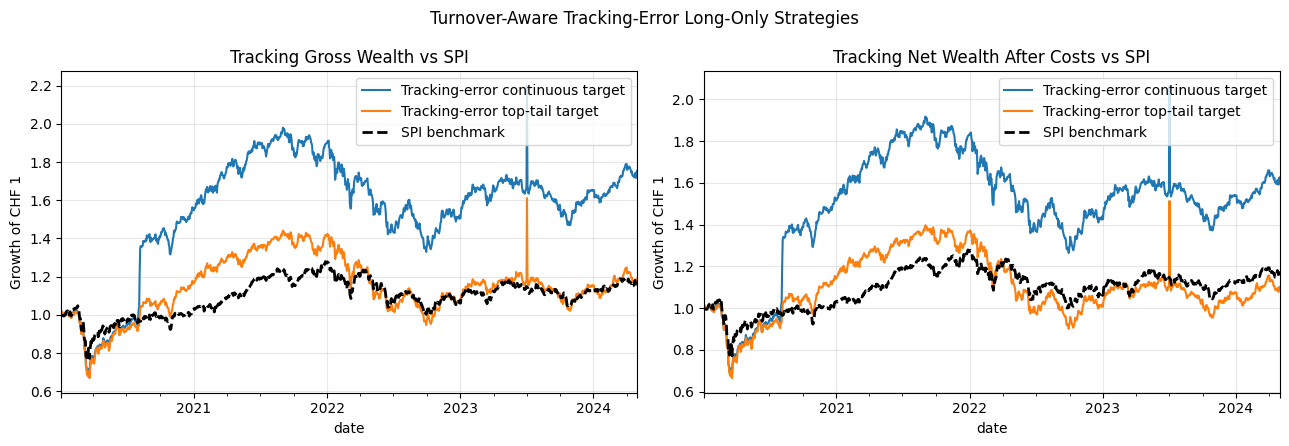

In [147]:
if CONFIG.run_tracking_error_strategies and tracking_strategy_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    tracking_benchmark_index = next(iter(tracking_strategy_results.values()))["net"].index
    tracking_spi_benchmark = spi_returns.reindex(tracking_benchmark_index).dropna()

    for name, result in tracking_strategy_results.items():
        (1 + result["gross"]).cumprod().plot(ax=axes[0], label=name, linewidth=1.5)
        (1 + result["net"]).cumprod().plot(ax=axes[1], label=name, linewidth=1.5)

    for ax in axes:
        (1 + tracking_spi_benchmark).cumprod().plot(
            ax=ax,
            label="SPI benchmark",
            color="black",
            linestyle="--",
            linewidth=2,
        )
        ax.set_ylabel("Growth of CHF 1")
        ax.grid(True, alpha=0.3)
        ax.legend()

    axes[0].set_title("Tracking Gross Wealth vs SPI")
    axes[1].set_title("Tracking Net Wealth After Costs vs SPI")
    fig.suptitle("Turnover-Aware Tracking-Error Long-Only Strategies")
    fig.tight_layout()
    plt.show()
else:
    print("Tracking-error wealth plots skipped.")


## Final Conclusion

The conclusion should compare three implementation layers for the same frozen signal: direct EWMA smoothing, cost-aware Black-Litterman allocation, and turnover-aware tracking-error optimization. A defensible assessment should combine net Sharpe, drawdown, turnover, `Gross bps per trade`, win rate, SPI-relative performance, factor-adjusted alpha and the implementation diagnostics specific to each optimizer.
